# Notebook 01. Adquisición de información

Este notebook descarga las fuentes geoespaciales y satelitales que alimentan el modelo. El perímetro urbano oficial proviene de la capa MGN_URB_ZONA_URBANA del DANE, descargada desde el geoportal Colombia en Mapas del IGAC. Las imágenes satelitales (Sentinel-1, Sentinel-2, VIIRS, Copernicus DEM, GHS-BUILT y WorldPop) se obtienen vía Google Earth Engine, mientras que la red vial y las huellas de edificios se descargan desde OpenStreetMap con `osmnx`. Las etiquetas de entrenamiento se construyen a partir del shapefile oficial de barrios de Cartagena publicado por Cartagena Cómo Vamos en su portal Open Data, seleccionando por nombre los barrios reconocidos como informales consolidados y como formales consolidados. Todos los productos de esta fase quedan en `data/raw/` para que las fases siguientes operen sobre datos locales sin volver a llamar a GEE.


## 0. Imports y configuración

In [ ]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Añadir la carpeta src al path para importar config
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.config import (
    DATA_RAW, DATA_PROC, CRS_TRABAJO, CRS_WGS,
    CIUDAD_NOMBRE, CARTAGENA_BBOX_WGS,
    FECHA_INICIO, FECHA_FIN, S2_CLOUD_PCT_MAX,
    TAMAÑO_CELDA_M, GEE_PROJECT,
    PERIMETRO_URBANO_SHP, DIVIPOLA_CARTAGENA,
    BARRIOS_SHP, BARRIOS_FORMALES, BARRIOS_INFORMALES,
)

import ee
import geemap
import geopandas as gpd
import osmnx as ox
import numpy as np
import pandas as pd
from shapely.geometry import box, Polygon
import matplotlib.pyplot as plt

print(f"Proyecto: {project_root}")
print(f"Datos crudos en: {DATA_RAW}")

Proyecto: /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena
Datos crudos en: /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw


## 1. Earth Engine
Primera vez: descomentar `ee.Authenticate()`.

In [ ]:
# ee.Authenticate()  # descomentar solo la primera vez
ee.Initialize(project=GEE_PROJECT)
print(f"Google Earth Engine inicializado (project={GEE_PROJECT})")

Google Earth Engine inicializado (project=ee-hectorcperez21)


## 2. Perímetro urbano oficial de Cartagena

Se utiliza la capa MGN_URB_ZONA_URBANA del Marco Geoestadístico Nacional 2024 del DANE, descargada del geoportal Colombia en Mapas del IGAC. De los 32 polígonos urbanos que tiene el distrito (cabecera principal más corregimientos), se filtra únicamente la cabecera urbana de Cartagena (DIVIPOLA 13001, zona urbana 000), con un área de aproximadamente 84 km². Esto descarta los corregimientos rurales (Bocachica, Barú, La Boquilla, Tierra Bomba y otros) que sumarían cerca de 580 km² adicionales no urbanos.

Esta delimitación se prefiere sobre el polígono administrativo de OpenStreetMap porque OSM devuelve el límite distrital completo, no el suelo urbano oficial reconocido por el Estado colombiano.


In [ ]:
print(f"Cargando perímetro urbano oficial DANE desde {PERIMETRO_URBANO_SHP}...")
perimetro_admin = gpd.read_file(PERIMETRO_URBANO_SHP).to_crs(CRS_WGS)
print(f"(ok) Perímetro DANE cargado: {len(perimetro_admin)} feature(s)")
print(perimetro_admin.drop(columns="geometry"))

# Área en km² para verificación
perimetro_utm_check = perimetro_admin.to_crs(CRS_TRABAJO)
area_km2 = perimetro_utm_check.geometry.area.sum() / 1e6
print(f"  Área de la cabecera urbana: {area_km2:.2f} km²")

Cargando perímetro urbano oficial DANE desde /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/cartagena_perimetro_urbano_dane/cartagena_perimetro_urbano_dane.shp...
(ok) Perímetro DANE cargado: 1 feature(s)
  divipola cod_zu                                             nombre  \
0    13001    000  CARTAGENA DE INDIAS, DISTRITO TURÍSTICO Y CULT...   

          fuente  
0  DANE MGN 2024  
  Área de la cabecera urbana: 83.57 km²


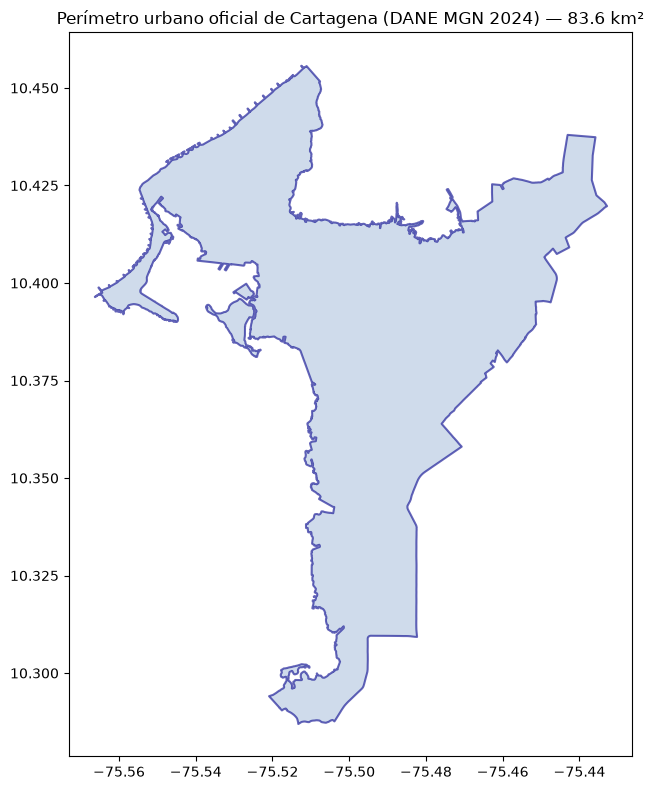

In [ ]:
# Visualización rápida
fig, ax = plt.subplots(figsize=(8, 8))
perimetro_admin.plot(ax=ax, facecolor="lightsteelblue", edgecolor="darkblue", linewidth=1.5, alpha=0.6)
ax.set_title(f"Perímetro urbano oficial de Cartagena (DANE MGN 2024) — {area_km2:.1f} km²")
plt.tight_layout()
plt.savefig(DATA_RAW / "fig_perimetro_urbano_dane.png", dpi=120)
plt.show()

ROI para GEE.

In [ ]:
# Se extrae la geometría del primer feature como GeoJSON
roi_geojson = perimetro_admin.geometry.iloc[0].__geo_interface__
roi_ee = ee.Geometry(roi_geojson)

# Verificación
area_km2 = roi_ee.area().getInfo() / 1e6
print(f"Área del polígono: {area_km2:.1f} km²")

Área del polígono: 84.0 km²


## 3. Sentinel-2. Reflectancias del compuesto mediano 2024

Se construye un compuesto anual mediano de Sentinel-2 SR Harmonized 2024 sobre el perímetro urbano. Se filtran escenas con menos del 30 % de cobertura nubosa y se aplica una máscara basada en la banda SCL para retener solo vegetación, suelo desnudo, agua y zonas con baja probabilidad de nubes. La descarga se hace a 30 m de resolución porque la grilla de análisis posterior es de 100 m y 30 m es suficiente para muestreo zonal, además de mantenerse bajo el límite de 50 MB de descarga directa de GEE.


In [ ]:
def mask_s2_clouds(image):
    """Enmascara nubes en Sentinel-2 SR usando la banda SCL (Scene Classification)."""
    scl = image.select("SCL")
    # Clases válidas: 4 (vegetación), 5 (suelo desnudo), 6 (agua), 7 (sin clasificar baja prob), 11 (nieve)
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)).Or(scl.eq(11))
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])


s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi_ee)
    .filterDate(FECHA_INICIO, FECHA_FIN)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", S2_CLOUD_PCT_MAX))
    .map(mask_s2_clouds)
)

s2_count = s2_collection.size().getInfo()
print(f"Sentinel-2 escenas filtradas: {s2_count}")

# Bandas espectrales clave + SWIR para índices urbanos
S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
s2_median = s2_collection.select(S2_BANDS).median().clip(roi_ee)

# Exportación local
# Nota técnica: Sentinel-2 nativo es 10 m, pero se descarga a 30 m para mantenernos
# bajo el límite de 50 MB de GEE para descargas directas. Como la grilla de análisis
# es de 100 m, los 30 m son ~3× más finos que la celda y suficientes para muestreo.
# Si se requiere mayor resolución para futuros análisis, exportar a Google Drive con
# ee.batch.Export.image.toDrive() permite resoluciones nativas sin límite de tamaño.
print("Descargando Sentinel-2 mediana (resolución 30 m, ~22 MB)...")
geemap.ee_export_image(
    s2_median,
    filename=str(DATA_RAW / "sentinel2_median_2024.tif"),
    scale=30,
    region=roi_ee,
    file_per_band=False,
)
print("(ok) Sentinel-2 descargado")

Sentinel-2 escenas filtradas: 26
Descargando Sentinel-2 mediana (resolución 30 m, ~22 MB)...
Generating URL ...
Please wait ...
Data downloaded to /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/sentinel2_median_2024.tif
(ok) Sentinel-2 descargado


## 4. Sentinel-1. Backscatter SAR

Compuesto mediano 2024 de Sentinel-1 GRD en polarizaciones VV y VH, modo IW y órbita ascendente. El radar es insensible a la cobertura nubosa, lo que lo hace particularmente útil en el Caribe colombiano, y captura la heterogeneidad estructural del tejido urbano. Se descarga a 20 m.


In [ ]:
s1_collection = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(roi_ee)
    .filterDate(FECHA_INICIO, FECHA_FIN)
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))
)

s1_count = s1_collection.size().getInfo()
print(f"Sentinel-1 escenas filtradas: {s1_count}")

s1_median = s1_collection.select(["VV", "VH"]).median().clip(roi_ee)

print("Descargando Sentinel-1 mediana (resolución 20 m)...")
geemap.ee_export_image(
    s1_median,
    filename=str(DATA_RAW / "sentinel1_median_2024.tif"),
    scale=20,
    region=roi_ee,
    file_per_band=False,
)
print("(ok) Sentinel-1 descargado")

Sentinel-1 escenas filtradas: 28
Descargando Sentinel-1 mediana (resolución 20 m)...
Generating URL ...
Please wait ...
Data downloaded to /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/sentinel1_median_2024.tif
(ok) Sentinel-1 descargado


## 5. GHS-BUILT-S 2020

Producto global del Joint Research Centre de la Comisión Europea que entrega la fracción construida por celda de 100 m. Sirve como indicador consistente y validado de presencia urbana.


In [ ]:
ghs_built = (
    ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S/2020")
    .select("built_surface")
    .clip(roi_ee)
)

print("Descargando GHS-BUILT-S 2020 (con chunks por si excede límite directo)...")
out_ghs = DATA_RAW / "ghs_built_s_2020.tif"
try:
    # Primero intento descarga directa (suele funcionar para áreas pequeñas)
    geemap.ee_export_image(
        ghs_built, filename=str(out_ghs),
        scale=100, region=roi_ee, crs="EPSG:32618",
    )
except Exception as e:
    print(f"ee_export_image falló ({e}), usando download_ee_image con tiles...")
    geemap.download_ee_image(
        ghs_built, filename=str(out_ghs),
        region=roi_ee, scale=100, crs="EPSG:32618",
    )

# Verificar
if out_ghs.exists() and out_ghs.stat().st_size > 1000:
    print(f"(ok) GHS-BUILT-S descargado ({out_ghs.stat().st_size / 1024:.1f} KB)")
else:
    raise RuntimeError(f"GHS-BUILT no se descargó correctamente. Archivo: {out_ghs}")

Descargando GHS-BUILT-S 2020 (con chunks por si excede límite directo)...
Generating URL ...
Please wait ...
Data downloaded to /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/ghs_built_s_2020.tif
(ok) GHS-BUILT-S descargado (18.4 KB)


## 6. VIIRS. Luces nocturnas

Compuesto anual VIIRS DNB del Earth Observation Group. La radiancia nocturna funciona como proxy del acceso a servicios eléctricos. Los asentamientos informales tienden a iluminación más baja o más irregular que los barrios formales consolidados.


In [ ]:
# VIIRS ANNUAL_V21 — compuesto anual consolidado del Earth Observation Group (EOG).
# Se toma la imagen más reciente disponible sin filtrar por año específico (más robusto).
viirs_coll = ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V21").select("average")
viirs = viirs_coll.sort("system:time_start", False).first().clip(roi_ee)

out_viirs = DATA_RAW / "viirs_2024.tif"
if out_viirs.exists():
    out_viirs.unlink()

print("Descargando VIIRS night lights...")
geemap.ee_export_image(
    viirs, filename=str(out_viirs),
    scale=500, region=roi_ee, crs="EPSG:32618",
)

if out_viirs.exists() and out_viirs.stat().st_size > 1000:
    print(f"(ok)VIIRS descargado ({out_viirs.stat().st_size / 1024:.1f} KB)")
else:
    raise RuntimeError(f"VIIRS falló — archivo vacío o ausente en {out_viirs}")

Descargando VIIRS night lights...
Generating URL ...
Please wait ...
Data downloaded to /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/viirs_2024.tif
(ok)VIIRS descargado (5.3 KB)


## 7. Copernicus DEM GLO-30

Modelo digital de elevación global a 30 m. La pendiente derivada captura el hecho documentado de que en Cartagena los asentamientos informales se concentran en pendientes pronunciadas de la Loma del Marión, el Cerro de La Popa y laderas adyacentes.


In [ ]:
dem = (
    ee.ImageCollection("COPERNICUS/DEM/GLO30")
    .select("DEM")
    .mosaic()
    .clip(roi_ee)
)

print("Descargando Copernicus DEM...")
geemap.ee_export_image(
    dem,
    filename=str(DATA_RAW / "dem_glo30.tif"),
    scale=30,
    region=roi_ee,
)
print("(ok) DEM descargado")

Descargando Copernicus DEM...
Generating URL ...
Please wait ...
An error occurred while downloading.
(ok) DEM descargado


## 8. WorldPop 2020

Densidad poblacional a 100 m (versión constrained) producida por la Universidad de Southampton. Sirve para confirmar áreas efectivamente habitadas dentro de la grilla.


In [ ]:
worldpop = (
    ee.ImageCollection("WorldPop/GP/100m/pop")
    .filterDate("2020-01-01", "2020-12-31")
    .filterBounds(roi_ee)
    .select("population")
    .mosaic()
    .clip(roi_ee)
)

print("Descargando WorldPop 2020...")
geemap.ee_export_image(
    worldpop,
    filename=str(DATA_RAW / "worldpop_2020.tif"),
    scale=100,
    region=roi_ee,
)
print("(ok)WorldPop descargado")

Descargando WorldPop 2020...
Generating URL ...
Please wait ...
Data downloaded to /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw/worldpop_2020.tif
(ok)WorldPop descargado


## 9. OpenStreetMap. Vías y edificios

Se descargan la red vial completa y las huellas de edificios mapeados en OSM dentro del perímetro urbano. Estas dos capas alimentan variables predictoras del modelo. En asentamientos informales el trazado vial tiende a ser más irregular, los edificios más pequeños, y la cobertura de mapeo OSM tiende a ser menor. Esta última asociación es un proxy útil pero sesgado, y se documenta como riesgo en la nota técnica.


In [ ]:
print("Descargando red vial OSM...")
G_roads = ox.graph_from_polygon(
    perimetro_admin.geometry.iloc[0],
    network_type="all",
    simplify=True,
)
nodes, edges = ox.graph_to_gdfs(G_roads)
edges = edges.reset_index()
edges.to_file(DATA_RAW / "osm_vias.gpkg", driver="GPKG")
print(f"(ok) Vías OSM: {len(edges)} segmentos")

Descargando red vial OSM...
(ok) Vías OSM: 62173 segmentos


In [ ]:
print("Descargando edificios OSM...")
buildings = ox.features_from_polygon(
    perimetro_admin.geometry.iloc[0],
    tags={"building": True},
)
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])]
buildings = buildings[["geometry"]].copy()
buildings.to_file(DATA_RAW / "osm_edificios.gpkg", driver="GPKG")
print(f"(ok) Edificios OSM: {len(buildings)} polígonos")

Descargando edificios OSM...
(ok) Edificios OSM: 39442 polígonos


## 10. Etiquetas positivas. Barrios informales

Se filtran los barrios informales consolidados desde la capa oficial de Cartagena Cómo Vamos: sub-sectores de Olaya Herrera, Nelson Mandela, El Pozón, Boston, San Francisco, Loma Fresca, Lo Amador, Fredonia, Henequén, Las Palmeras, Albornoz, Villas Barraza, Villa Fanny, Villa Rubia, Villa Hermosa, Villa Sandra, Nueva Jerusalén, Nuevo Paraíso, Nuevo Porvenir, Juan XXIII y Las Gaviotas, entre otros. La selección está distribuida por toda la ciudad (norte, oriente y sur) para evitar el sesgo geográfico que introduciría concentrar etiquetas en una sola zona.

Fuente: https://ccv-cgenacomovamos.opendata.arcgis.com/datasets/082b22be401f42bc9972e9e67d655db1/about


In [ ]:
barrios = gpd.read_file(BARRIOS_SHP).to_crs(CRS_WGS)
print(f"Total barrios CCV: {len(barrios)}")

# Filtrar informales
mask_inf = barrios["NOMBRE"].isin(BARRIOS_INFORMALES)
zona_norte = barrios[mask_inf][["NOMBRE", "geometry"]].copy()
zona_norte.columns = ["sector", "geometry"]
zona_norte["clase"] = "informal_preliminar"

# Verificación: cuáles esperados no aparecieron
faltantes = set(BARRIOS_INFORMALES) - set(zona_norte["sector"].tolist())
if faltantes:
    print(f"Barrios informales NO encontrados en el shapefile: {sorted(faltantes)}")

zona_norte.to_file(DATA_RAW / "etiquetas_positivas_zona_norte.gpkg", driver="GPKG")
print(f"(ok) Positivos (barrios informales CCV): {len(zona_norte)}")
print(zona_norte["sector"].tolist())

Total barrios CCV: 213
(ok) Positivos (barrios informales CCV): 35
['SAN FRANCISCO', 'LOMA FRESCA', 'LO AMADOR', 'EL POZON', 'BOSTON', 'LAS GAVIOTAS', 'NUEVO PORVENIR', 'LAS PALMERAS', 'JUAN XXIII', 'VILLA SANDRA', 'VILLA RUBIA', 'NELSON MANDELA', 'NUEVA JERUSALEN', 'VILLA BARRAZA', 'VILLA FANNY', 'ARROZ BARATO', 'POLICARPA', 'FREDONIA', 'NUEVO PARAISO', 'OLAYA ST. RAFAEL NUÑEZ', 'OLAYA VILLA OLIMPICA', 'OLAYA ST.11 DE NOVIEMBRE', 'OLAYA ST. RICAURTE', 'OLAYA ST. CENTRAL', 'OLAYA ST. LA MAGDALENA', 'OLAYA ST. LA PUNTILLA', 'OLAYA ST. PROGRESO', 'OLAYA ST. STELLA', 'OLAYA ST. ZARABANDA', 'VILLA HERMOSA', 'OLAYA ST. PLAYA BLANCA', 'ALBORNOZ', 'HENEQUEN', 'OLAYA ST. LA PUNTILLA', 'OLAYA ST. PLAYA BLANCA']


## 11. Etiquetas negativas. Barrios formales

Se filtran los barrios formales consolidados desde la misma fuente CCV. La selección mezcla deliberadamente barrios formales altos (Centro Histórico, Bocagrande, Castillogrande, Manga, Crespo, Marbella) con barrios formales populares consolidados (Daniel Lemaitre, Torices, El Bosque, Blas de Lezo, Los Cerros, La Castellana, La Esmeralda, entre otros). Esta mezcla le ofrece al modelo una frontera real entre informalidad y formalidad modesta, no solo el contraste fácil con sectores residenciales de clase alta.

Fuente: https://ccv-cgenacomovamos.opendata.arcgis.com/datasets/082b22be401f42bc9972e9e67d655db1/about


In [ ]:
mask_for = barrios["NOMBRE"].isin(BARRIOS_FORMALES)
formales_gdf = barrios[mask_for][["NOMBRE", "geometry"]].copy()
formales_gdf.columns = ["barrio", "geometry"]
formales_gdf["clase"] = "formal"

faltantes_for = set(BARRIOS_FORMALES) - set(formales_gdf["barrio"].tolist())
if faltantes_for:
    print(f"Barrios formales NO encontrados: {sorted(faltantes_for)}")

formales_gdf.to_file(DATA_RAW / "etiquetas_negativas_barrios_formales.gpkg", driver="GPKG")
print(f"(ok) Negativos (barrios formales CCV): {len(formales_gdf)}")
print(formales_gdf["barrio"].tolist())

(ok) Negativos (barrios formales CCV): 40
['DANIEL LEMAITRE', 'TORICES', 'SAN DIEGO', 'PIE DE LA POPA', 'AMBERES', 'ARMENIA', 'BRUSELAS', 'CHIQUINQUIRA', 'ESCALLON VILLA', 'LOS ALPES', 'LOS EJECUTIVOS', 'LA CASTELLANA', 'LOS ANGELES', 'LA CAMPIÑA', 'LOS CERROS', 'NUEVO BOSQUE', 'BUENOS AIRES', 'LAS DELICIAS', 'SAN PEDRO', 'ALTO BOSQUE', 'BLAS DE LEZO', 'SANTA MONICA', 'LOS CARACOLES', 'LOS CORALES', 'LOS JARDINES', 'LA ESMERALDA I', 'LA ESMERALDA II', 'MARBELLA', 'BOCAGRANDE', 'CENTRO', 'CRESPO', 'EL LAGUITO', 'LA MATUNA', 'GETSEMANI', 'EL CABRERO', 'LA CAROLINA', 'MANGA', 'CASTILLOGRANDE', 'PIE DEL CERRO', 'EL BOSQUE']


## 12. Grilla de análisis

Se construye una grilla regular de 100 m × 100 m sobre la cabecera urbana en EPSG:32618 (WGS 84 / UTM 18N). Cada celda es la unidad de análisis del modelo. La resolución de 100 m se eligió por coincidir con la resolución nativa de GHS-BUILT y WorldPop (lo que evita artefactos de remuestreo), ser apropiada al propósito de focalización a escala barrial, y mantener un volumen computacional manejable (alrededor de 9,000 celdas iniciales).


Grilla generada: 9,004 celdas de 100 m × 100 m


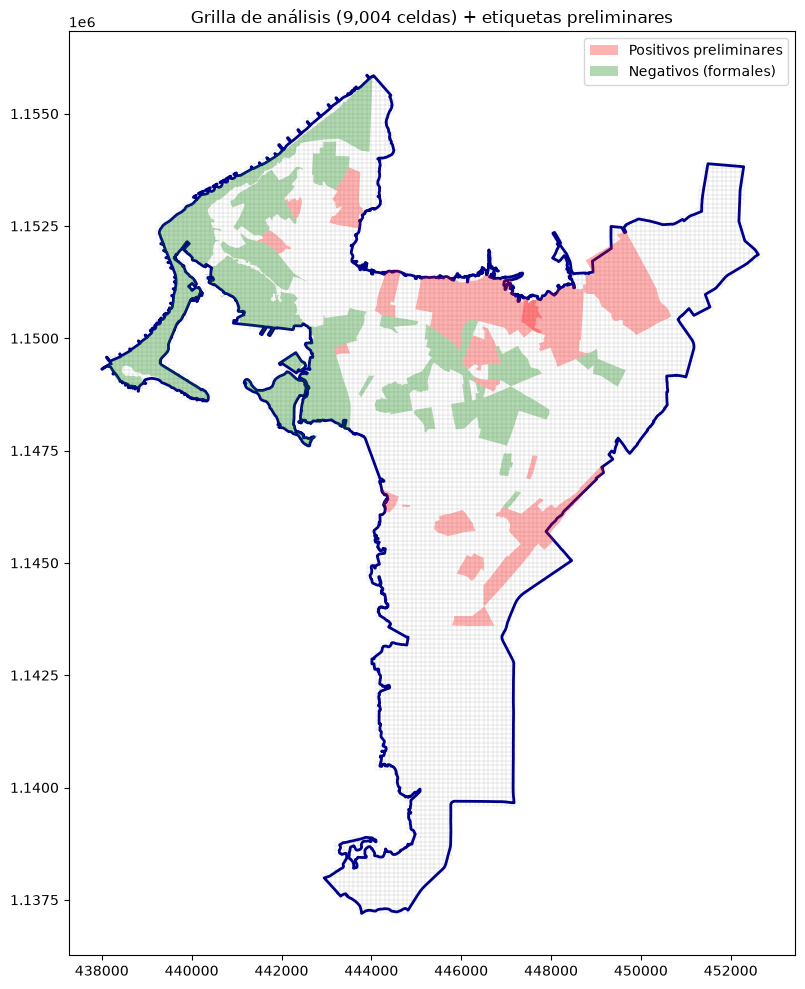

In [ ]:
# Reproyectar perímetro al CRS de trabajo
perimetro_utm = perimetro_admin.to_crs(CRS_TRABAJO)
xmin, ymin, xmax, ymax = perimetro_utm.total_bounds

# Generar grilla
xs = np.arange(xmin, xmax, TAMAÑO_CELDA_M)
ys = np.arange(ymin, ymax, TAMAÑO_CELDA_M)

cells = []
for x in xs:
    for y in ys:
        cells.append(box(x, y, x + TAMAÑO_CELDA_M, y + TAMAÑO_CELDA_M))

grilla = gpd.GeoDataFrame(geometry=cells, crs=CRS_TRABAJO)

# Mantener solo celdas que intersectan el perímetro urbano
grilla = grilla[grilla.intersects(perimetro_utm.geometry.iloc[0])].copy()
grilla = grilla.reset_index(drop=True)
grilla["cell_id"] = grilla.index

print(f"Grilla generada: {len(grilla):,} celdas de {TAMAÑO_CELDA_M} m × {TAMAÑO_CELDA_M} m")
grilla.to_file(DATA_PROC / "grilla_100m.gpkg", driver="GPKG")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 10))
grilla.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.2)
perimetro_utm.plot(ax=ax, facecolor="none", edgecolor="darkblue", linewidth=2)
zona_norte.to_crs(CRS_TRABAJO).plot(ax=ax, color="red", alpha=0.3, label="Positivos preliminares")
formales_gdf.to_crs(CRS_TRABAJO).plot(ax=ax, color="green", alpha=0.3, label="Negativos (formales)")
ax.set_title(f"Grilla de análisis ({len(grilla):,} celdas) + etiquetas preliminares")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_RAW / "fig_grilla_y_etiquetas.png", dpi=120)
plt.show()

## 13. Resumen de archivos descargados

In [ ]:
archivos_raw = sorted(DATA_RAW.glob("*"))
print(f"\nArchivos en {DATA_RAW}:")
for f in archivos_raw:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:<55} {size_mb:>8.2f} MB")

print(f"\nArchivos en {DATA_PROC}:")
for f in sorted(DATA_PROC.glob("*")):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:<55} {size_mb:>8.2f} MB")


Archivos en /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/raw:
  cartagena_perimetro_urbano_dane                             0.00 MB
  dem_glo30.tif                                               0.68 MB
  etiquetas_negativas_barrios_formales.gpkg                   0.22 MB
  etiquetas_positivas_zona_norte.gpkg                         0.14 MB
  fig_grilla_y_etiquetas.png                                  0.18 MB
  fig_perimetro_urbano_dane.png                               0.09 MB
  ghs_built_s_2020.tif                                        0.02 MB
  osm_edificios.gpkg                                          9.65 MB
  osm_vias.gpkg                                              14.61 MB
  sentinel1_median_2024.tif                                  10.50 MB
  sentinel2_median_2024.tif                                   7.47 MB
  viirs_2024.tif                                              0.01 MB
  worldpop_2020.tif                   

---
## Adquisición completada

Siguiente paso: `02_feature_engineering.py` -> calcular índices espectrales, texturas,
variables topográficas y agregaciones OSM por celda.